# Baseline notebook

Create model baseline and analysis for it

In [42]:
import pandas as pd 
import numpy as np

pd.set_option('display.max_columns', 200)
np.random.seed(42)

In [43]:
%pip install -q kagglehub

In [44]:
# download dataset from kaggle
import kagglehub # pyright: ignore[reportMissingImports]
from pathlib import Path

# Download latest version
path = Path(kagglehub.dataset_download("blastchar/telco-customer-churn"))
path = path / r"WA_Fn-UseC_-Telco-Customer-Churn.csv"

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'telco-customer-churn' dataset.
Path to dataset files: /kaggle/input/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv


In [45]:
df = pd.read_csv(path)
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Data preparation (From EDA)

In [46]:
to_category_columns = (
    [
        "gender",
        "Partner",
        "Dependents",
        "PhoneService",
        "MultipleLines",
        "InternetService",
        "OnlineSecurity",
        "OnlineBackup", 
        "DeviceProtection",
        "TechSupport",
        "StreamingTV", 
        "StreamingMovies",
        "Contract",
        "PaperlessBilling",
        "PaymentMethod",
        "Churn"
        ])
    
for column in to_category_columns:
    df[column] = df[column].astype("category")
    
df["SeniorCitizen"] = df["SeniorCitizen"] == 1
#FIXME: take a look later
df["Churn"] = df["Churn"] == "Yes"
    
df["TotalCharges"]  = pd.to_numeric(df['TotalCharges'], errors='coerce')

df = df.dropna()
df["TotalCharges"].isna().sum()

print("Data preparation is done")
df.shape

Data preparation is done


(7032, 21)

## Model building

In [47]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [48]:
# Drop customerId column as never significant
df = df.drop(columns="customerID")
df.shape

(7032, 20)

In [49]:
from sklearn.preprocessing import LabelEncoder # type: ignore

df_ohe = pd.get_dummies(df)
df_ohe.shape

(7032, 46)

In [50]:
from sklearn.model_selection import cross_val_predict, StratifiedKFold
from sklearn.metrics import classification_report, average_precision_score
from sklearn.ensemble import RandomForestClassifier

X = df_ohe.drop(columns="Churn").copy()
y = df_ohe["Churn"].copy()

rf = RandomForestClassifier(random_state=42)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

y_pred_cv = cross_val_predict(rf, X, y, cv=skf)
y_proba_cv = cross_val_predict(rf, X, y, cv=skf, method="predict_proba")[:, 1]
auc_score = average_precision_score(y, y_proba_cv)
print(classification_report(y, y_pred_cv))
print(f"PR-AUC: {auc_score:.4f}")

              precision    recall  f1-score   support

       False       0.83      0.90      0.86      5163
        True       0.64      0.48      0.55      1869

    accuracy                           0.79      7032
   macro avg       0.73      0.69      0.70      7032
weighted avg       0.78      0.79      0.78      7032

PR-AUC: 0.6075


### Metrics explained

It simpler to explain on one class. I will use where Churn is True

Class True (Churn is True):
- Precision 0.64 — when model predicts "churn", it's correct only 64% of the time
- Recall 0.48 — it catches only 48% of actual churners
- PR-AUC 0.81 - how model is confident in class splitting. Will the customer with the biggest confidence actually churned one

Same logic for the not churned users

As we are trying to minimize missed by model churns (FN error that costs business big money). We should maximize recall on True class.

Despite model performs well on false classes (can classify not churning customers) it's perform nearly a coin flip predict on actually churned ones. Such conduct can be caused by class imbalance (roughly $\approx30%$% customers from data were churned)

## Data imbalance handling

Let's evaluate class imbalance handling methods

In [51]:
churn_ratio = df_ohe.groupby("Churn")["Churn"].count()
churn_ratio

,Churn
Churn,
False,5163
True,1869


In [52]:
print(f"Churned to not churned ratio is {churn_ratio.iloc[1] / churn_ratio.iloc[0]:.2f}")

Churned to not churned ratio is 0.36


### Model tuning (class_weight = 'balanced')

In [53]:
# Simply change parameter in model
rf = RandomForestClassifier(random_state=42, class_weight="balanced")

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

y_pred_cv = cross_val_predict(rf, X, y, cv=skf)
y_proba_cv = cross_val_predict(rf, X, y, cv=skf, method="predict_proba")[:, 1]
auc_score = average_precision_score(y, y_proba_cv)
print(classification_report(y, y_pred_cv))
print(f"PR-AUC: {auc_score:.4f}")

              precision    recall  f1-score   support

       False       0.83      0.90      0.86      5163
        True       0.64      0.48      0.55      1869

    accuracy                           0.79      7032
   macro avg       0.73      0.69      0.71      7032
weighted avg       0.78      0.79      0.78      7032

PR-AUC: 0.6123


Metrics do not change at all. Class weights do not bring significant result

AUC score increased slightly but not significant

### Using GBDT model

As GBDT models are robust to class imbalance I will perform analysis also

I will train a LightGBM as GBDT model with simple `is_unbalanced` parameter for handling data imbalance

In [54]:
%pip install lightgbm -q

In [55]:
import lightgbm as lgb

lgbm = lgb.LGBMClassifier(is_unbalance=True, verbose=-1)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

y_pred_cv = cross_val_predict(lgbm, X, y, cv=skf)
y_proba_cv = cross_val_predict(lgbm, X, y, cv=skf, method="predict_proba")[:, 1]
auc_score = average_precision_score(y, y_proba_cv)
print(classification_report(y, y_pred_cv))
print(f"PR-AUC: {auc_score:.4f}")

              precision    recall  f1-score   support

       False       0.89      0.76      0.82      5163
        True       0.53      0.75      0.62      1869

    accuracy                           0.76      7032
   macro avg       0.71      0.75      0.72      7032
weighted avg       0.80      0.76      0.77      7032

PR-AUC: 0.6507


GBDT with native data imbalance handling parameter performs much better than random forest. We gain 75% recall on our churned customers that is a good result for almost not tuned model

Also AUC score increased by 5% compared to baseline

### Undersampling

In [56]:
from imblearn.pipeline import Pipeline
from imblearn.under_sampling import RandomUnderSampler

X = df_ohe.drop(columns="Churn").copy()
y = df_ohe["Churn"].copy()

pipeline = Pipeline([
    ("undersample", RandomUnderSampler(random_state=42)),
    ("rf", RandomForestClassifier(random_state=42))
])

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
y_pred_cv = cross_val_predict(pipeline, X, y, cv=skf)
y_proba_cv = cross_val_predict(pipeline, X, y, cv=skf, method="predict_proba")[:, 1]
auc_score = average_precision_score(y, y_proba_cv)
print(classification_report(y, y_pred_cv))
print(f"PR-AUC: {auc_score:.4f}")

              precision    recall  f1-score   support

       False       0.89      0.73      0.80      5163
        True       0.51      0.76      0.61      1869

    accuracy                           0.74      7032
   macro avg       0.70      0.74      0.71      7032
weighted avg       0.79      0.74      0.75      7032

PR-AUC: 0.6088


Undersampled metrics are quite impressive. We achieve score like a GBDT model but using baseline. Undersample have decrease metrics on False classes (Model do more FP mistakes, thinking that customer will churn, while he will not). For our case this is acceptable (we are focusing on detecting True classes)

AUC score at the same level as baseline one

### Oversampling

#### Boostrap oversampling

Oversampling that will simply boostrap minority class

In [57]:
from imblearn.over_sampling import RandomOverSampler

X = df_ohe.drop(columns="Churn").copy()
y = df_ohe["Churn"].copy()

pipeline = Pipeline([
    ("oversample", RandomOverSampler(random_state=42)),
    ("rf", RandomForestClassifier(random_state=42))
])

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
y_pred_cv = cross_val_predict(pipeline, X, y, cv=skf)
y_proba_cv = cross_val_predict(pipeline, X, y, cv=skf, method="predict_proba")[:, 1]
auc_score = average_precision_score(y, y_proba_cv)
print(classification_report(y, y_pred_cv))
print(f"PR-AUC: {auc_score:.4f}")

              precision    recall  f1-score   support

       False       0.85      0.86      0.85      5163
        True       0.59      0.58      0.59      1869

    accuracy                           0.78      7032
   macro avg       0.72      0.72      0.72      7032
weighted avg       0.78      0.78      0.78      7032

PR-AUC: 0.5972


Boostrap oversampling improves our metrics but not that much as undersampling. Also it decrease the PR-AUC metric

#### SMOTE (SMOTENC) oversampling

Interpolate points to balance minority class

SMOTENC is a modification that handles mixed numerical and categorical features natively, so it works directly on the original dataframe

In [58]:
from imblearn.over_sampling import SMOTENC

X = df.drop(columns="Churn").copy()
y = df["Churn"].copy()

cat_cols = X.select_dtypes(include=["category", "bool"]).columns.tolist()

# Convert categories to integers for SMOTENC
for col in cat_cols:
    X[col] = X[col].cat.codes if X[col].dtype.name == "category" else X[col].astype(int)

pipeline = Pipeline([
    ("smotenc", SMOTENC(categorical_features=cat_cols, random_state=42)),
    ("rf", RandomForestClassifier(random_state=42))
])

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
y_pred_cv = cross_val_predict(pipeline, X, y, cv=skf)
y_proba_cv = cross_val_predict(pipeline, X, y, cv=skf, method="predict_proba")[:, 1]
auc_score = average_precision_score(y, y_proba_cv)
print(classification_report(y, y_pred_cv))
print(f"PR-AUC: {auc_score:.4f}")

              precision    recall  f1-score   support

       False       0.85      0.85      0.85      5163
        True       0.58      0.58      0.58      1869

    accuracy                           0.78      7032
   macro avg       0.72      0.72      0.72      7032
weighted avg       0.78      0.78      0.78      7032

PR-AUC: 0.6039


SMOTE give us metrics similar to bootstrapping oversample. The cause might be that the data is mostly categorial with only 3 numeric features. Interpolation between points mostly duplicates categorical features causing bootstrapping with noise in numeric features

AUC score near baseline again

### GBDT + undersampling

In [59]:
X = df_ohe.drop(columns="Churn").copy()
y = df_ohe["Churn"].copy()

pipeline = Pipeline([
    ("undersample", RandomUnderSampler(random_state=42)),
    ("lgb", lgb.LGBMClassifier(is_unbalance=True, verbose=-1))
])

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
y_pred_cv = cross_val_predict(pipeline, X, y, cv=skf)
y_proba_cv = cross_val_predict(pipeline, X, y, cv=skf, method="predict_proba")[:, 1]
auc_score = average_precision_score(y, y_proba_cv)
print(classification_report(y, y_pred_cv))
print(f"PR-AUC: {auc_score:.4f}")

              precision    recall  f1-score   support

       False       0.90      0.72      0.80      5163
        True       0.50      0.77      0.61      1869

    accuracy                           0.74      7032
   macro avg       0.70      0.75      0.70      7032
weighted avg       0.79      0.74      0.75      7032

PR-AUC: 0.6290


GBDT with undersampling slightly improved our recall and decrease precision

But AUC score is lower that an GBDT model approach itself

## Conclusion

Plot of experiments for better analysis experience

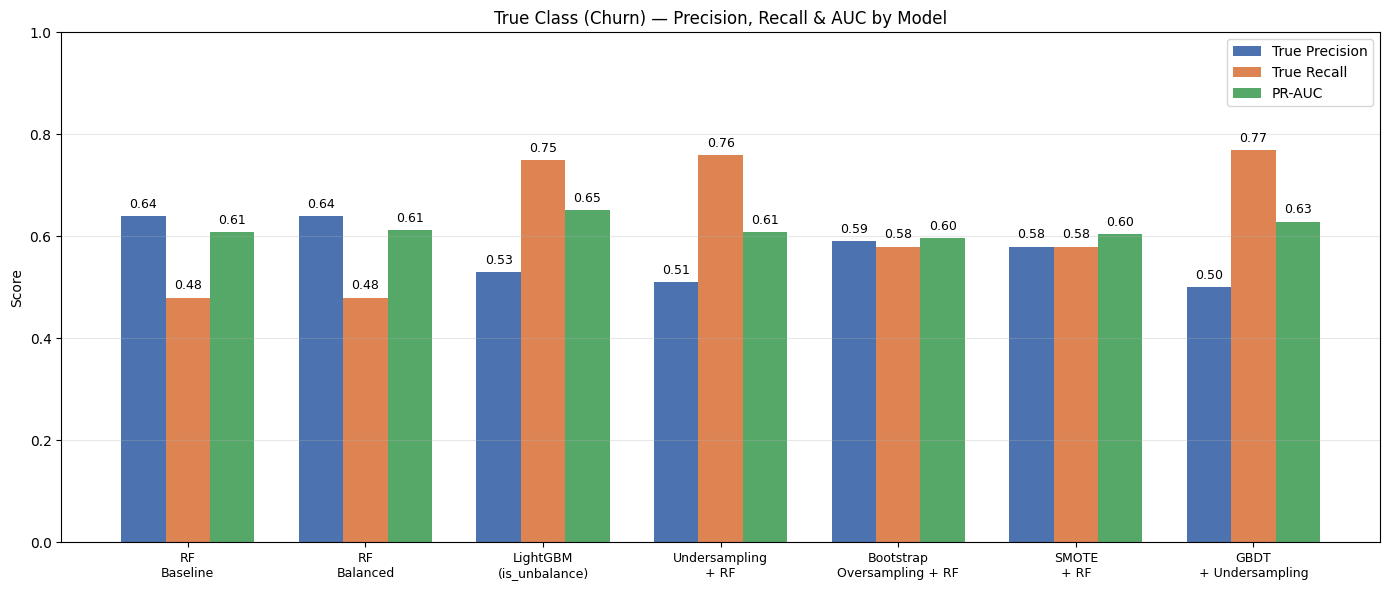

In [61]:
import matplotlib.pyplot as plt

models = [
    "RF\nBaseline",
    "RF\nBalanced",
    "LightGBM\n(is_unbalance)",
    "Undersampling\n+ RF",
    "Bootstrap\nOversampling + RF",
    "SMOTE\n+ RF",
    "GBDT\n+ Undersampling",
]

true_recall = [0.48, 0.48, 0.75, 0.76, 0.58, 0.58, 0.77]
true_precision = [0.64, 0.64, 0.53, 0.51, 0.59, 0.58, 0.50]
true_auc = [0.6075, 0.6123, 0.6507, 0.6088, 0.5972, 0.6039, 0.6290]

x = np.arange(len(models))
width = 0.25

fig, ax = plt.subplots(figsize=(14, 6))
bars1 = ax.bar(x - width, true_precision, width, label="True Precision", color="#4C72B0")
bars2 = ax.bar(x, true_recall, width, label="True Recall", color="#DD8452")
bars3 = ax.bar(x + width, true_auc, width, label="PR-AUC", color="#55A868")

ax.set_ylabel("Score")
ax.set_title("True Class (Churn) — Precision, Recall & AUC by Model")
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=9)
ax.set_ylim(0, 1)
ax.legend()
ax.grid(axis="y", alpha=0.3)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01, f"{bar.get_height():.2f}", ha="center", va="bottom", fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01, f"{bar.get_height():.2f}", ha="center", va="bottom", fontsize=9)
for bar in bars3:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01, f"{bar.get_height():.2f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()


From plot we see that best approaches are using GBDT model with imbalance param or using an udersample technic

But all our manipulations with data decrease model precision from 0.68 to ~0.5. That means if model predict 10 churned people 5 will be actually churned. That leads to big potential losses on FP errors ($38$) and should be threated with PR-ROC curve analysis

From AUC score the best one is GBDT but the benefit is near the baseline one

## Recomendations

- Use an GBDT approach with class balance parameter
    - Or use an undersampling approach with Random Forest
- Analyze PR-ROC curve and manage best threshhold for predictions